In [16]:
import tensorflow as tf
import numpy as np
import os
import PIL
import PIL.Image
import tensorflow_datasets as tfds
import pathlib
import random
import matplotlib.pyplot as plt
import h5py
from tensorflow.keras import regularizers

In [15]:
!pip install -q --force-reinstall \
    "protobuf==5.29.6" \
    "tensorflow-metadata==1.17.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.5/320.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 19.8 MB/s eta 0:00:00


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
base_dir = '/content/drive/MyDrive/Final Project/Facial images dataset for Autism Detection/train'
autistic_dir = os.path.join(base_dir,'autistic')
non_autistic_dir = os.path.join(base_dir,'non_autistic')

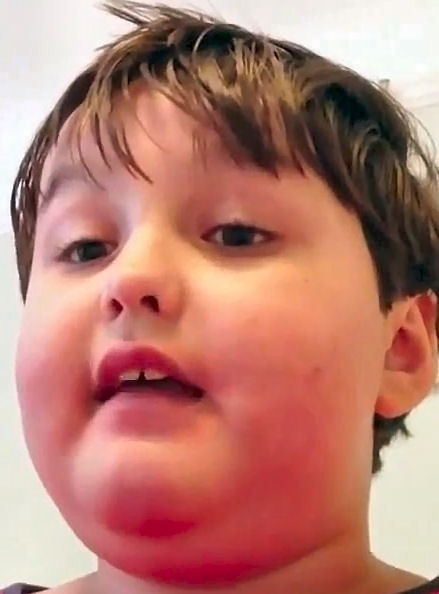

In [19]:
random_image = random.sample(os.listdir(autistic_dir),1)
img = tf.keras.utils.load_img(f'{autistic_dir}/{random_image[0]}')
img

In [34]:
from sklearn.model_selection import train_test_split

SEED = 42
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

class_names = ["autistic", "non_autistic"]
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

file_paths = []
labels = []

for label, class_name in enumerate(class_names):
    class_directory = pathlib.Path(base_dir) / class_name

    class_files = [
        str(path)
        for path in class_directory.rglob("*")
        if path.suffix.lower() in valid_extensions
    ]

    file_paths.extend(class_files)
    labels.extend([label] * len(class_files))

file_paths = np.array(file_paths)
labels = np.array(labels)

# 80% training, 20% temporary.
train_paths, temporary_paths, train_labels, temporary_labels = (
    train_test_split(
        file_paths,
        labels,
        test_size=0.20,
        stratify=labels,
        random_state=SEED
    )
)

# Divide the remaining 20% into 10% validation and 10% test.
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temporary_paths,
    temporary_labels,
    test_size=0.50,
    stratify=temporary_labels,
    random_state=SEED
)

def load_image(path, label):
    image = tf.io.read_file(path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE, antialias=True)

    return image, tf.cast(label, tf.float32)

def make_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Training images: 2020
Validation images: 253
Test images: 253


In [35]:
val_ds = tf.keras.utils.image_dataset_from_directory(base_dir, validation_split=0.2, subset='validation', image_size = (180,180), batch_size=32, seed=42)

Found 2526 files belonging to 2 classes.
Using 505 files for validation.


In [38]:
# The manually created dataset doesn't have .class_names attribute
# We use the class_names list defined in cell J8fdUNq2gkOK
print(f"Class names: {class_names}")

Class names: ['autistic', 'non_autistic']


In [39]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [40]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=43),
    tf.keras.layers.RandomRotation(0.1, seed=43),
    tf.keras.layers.RandomZoom(0.2),  # Randomly zoom in on images
    tf.keras.layers.RandomContrast(0.2)  # Randomly adjust contrast of the images
])


In [41]:
val_ds1=val_ds.shard(num_shards=2, index=0)
test_ds=val_ds.shard(num_shards=2, index=1)
val_ds = val_ds1

## **CNN**

In [11]:
NUM_CLASSES = len(class_names)
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,982,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,429,186 (9.27 MB)

 Trainable params: 2,429,186 (9.27 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [14]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15,
)

Epoch 1/15
49/64 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.5340 - loss: 0.8111

KeyboardInterrupt: 

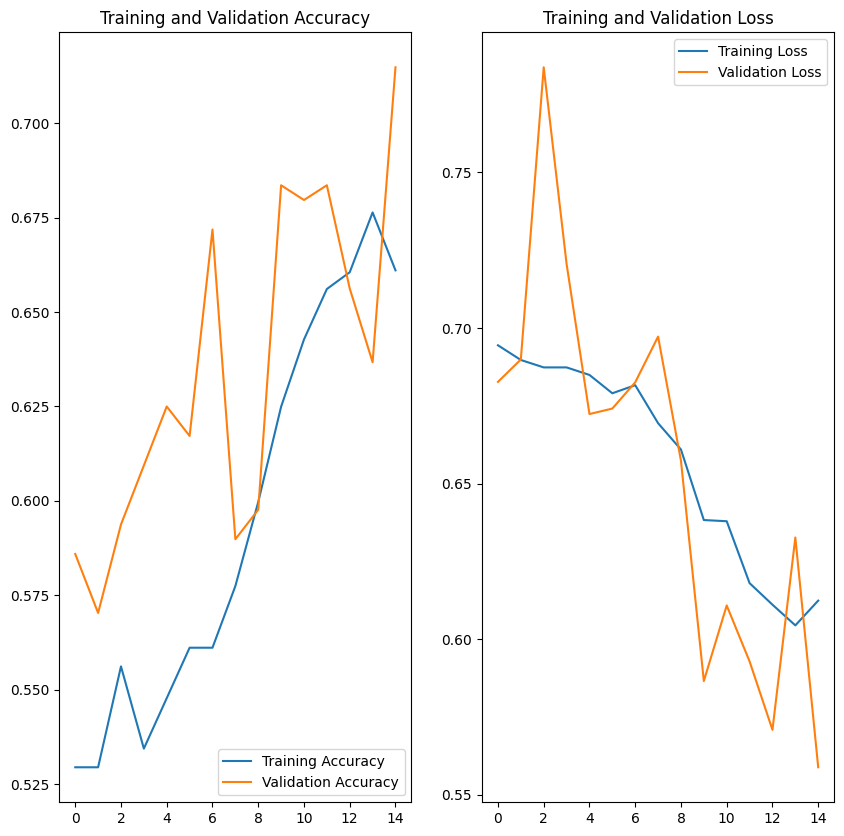

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **Enhanced CNN with Dropout and Regularization**

In [ ]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.3),  # Added dropout

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.3),  # Added dropout

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.3),  # Added dropout

    tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.3),  # Added dropout

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
model_2.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

In [ ]:
model_2.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [ ]:
model_2.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint, reduce_lr]
)

Epoch 1/15
64/64 [==============================] - 11s 158ms/step - loss: 0.5922 - accuracy: 0.6719 - val_loss: 0.6003 - val_accuracy: 0.6406 - lr: 0.0010
Epoch 2/15


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


64/64 [==============================] - 11s 162ms/step - loss: 0.5981 - accuracy: 0.6813 - val_loss: 0.5789 - val_accuracy: 0.6953 - lr: 0.0010
Epoch 3/15
64/64 [==============================] - 11s 161ms/step - loss: 0.5855 - accuracy: 0.6863 - val_loss: 0.6292 - val_accuracy: 0.6250 - lr: 0.0010
Epoch 4/15
64/64 [==============================] - 10s 142ms/step - loss: 0.5785 - accuracy: 0.6818 - val_loss: 0.6025 - val_accuracy: 0.6445 - lr: 0.0010
Epoch 5/15
64/64 [==============================] - 11s 163ms/step - loss: 0.5680 - accuracy: 0.6967 - val_loss: 0.5889 - val_accuracy: 0.6406 - lr: 0.0010
Epoch 6/15
64/64 [==============================] - 11s 157ms/step - loss: 0.5637 - accuracy: 0.6992 - val_loss: 0.5359 - val_accuracy: 0.7188 - lr: 2.0000e-04
Epoch 7/15
64/64 [==============================] - 10s 143ms/step - loss: 0.5626 - accuracy: 0.7011 - val_loss: 0.5464 - val_accuracy: 0.6953 - lr: 2.0000e-04
Epoch 8/15
64/64 [==============================] - 11s 162ms/step 

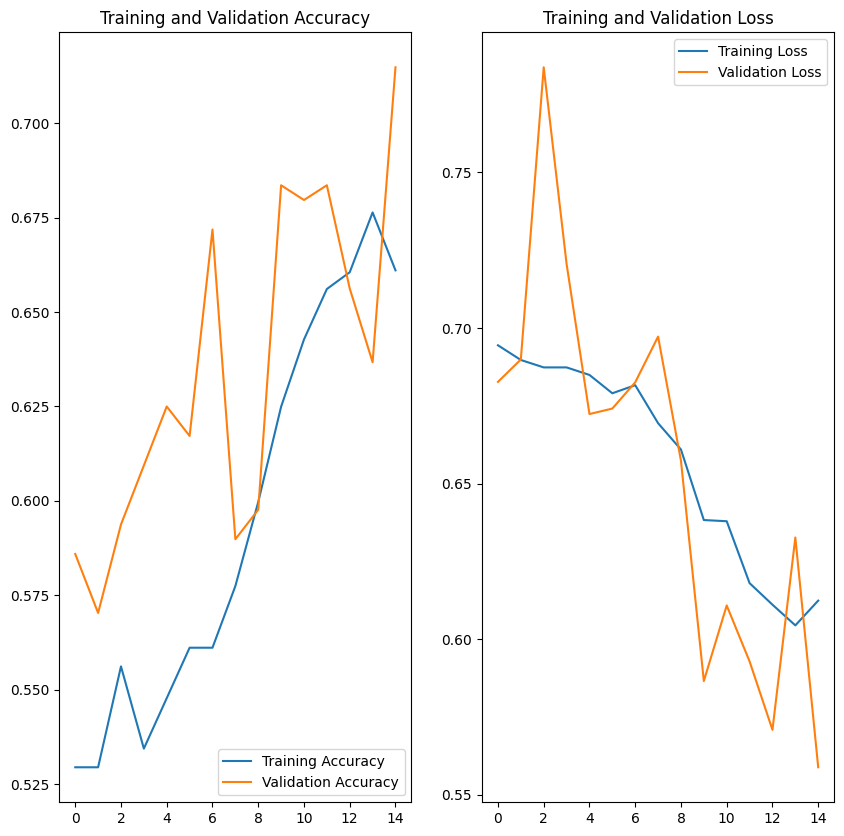

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **Deep CNN**

In [29]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    data_augmentation,
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),  # Adding dropout

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),  # Adding dropout

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),  # Adding dropout

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
model_3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 123904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │   126,878,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,251,586 (485.43 MB)

 Trainable params: 127,251,586 (485.43 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model_3.h5', monitor='val_accuracy', save_best_only=True, save_weights_only=False)



In [32]:
model_3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [33]:
history = model_3.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5012 - loss: 2.9273

64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 439ms/step - accuracy: 0.4834 - loss: 1.3341 - val_accuracy: 0.4609 - val_loss: 0.6933
Epoch 2/15
33/64 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.4787 - loss: 0.6934

KeyboardInterrupt: 

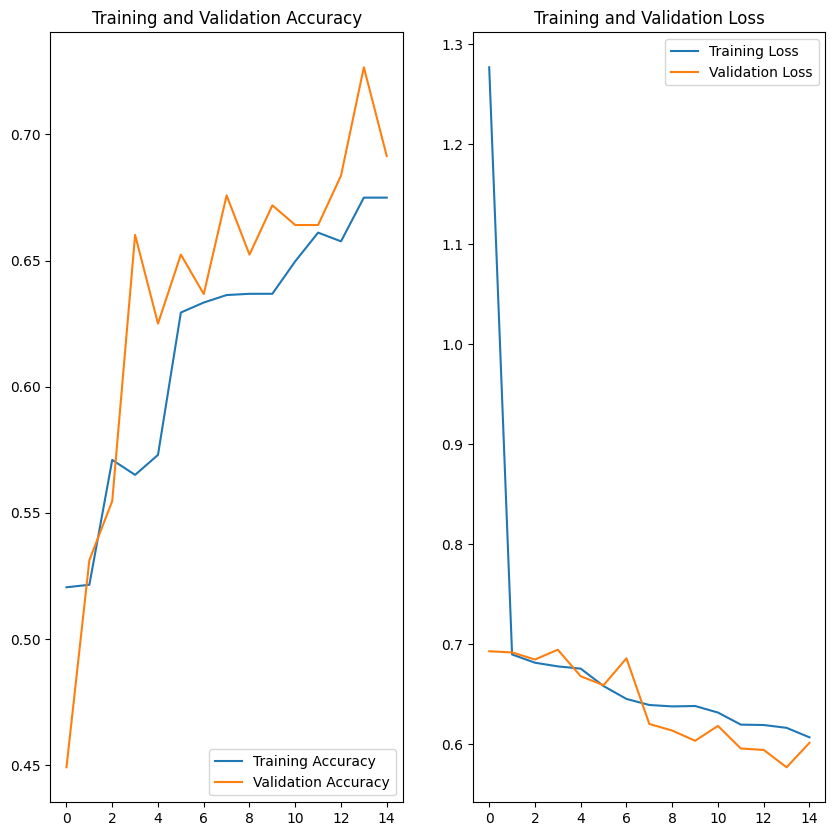

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **DNN**

In [ ]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(180, 180, 3)),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001)),  # Reduced regularization
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),  # Reduced regularization
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
model_4.summary()

In [ ]:
model_4.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

In [ ]:
history = model_4.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds
)

Epoch 1/15
64/64 [==============================] - 26s 349ms/step - loss: 22.5358 - accuracy: 0.5562 - val_loss: 13.1952 - val_accuracy: 0.6016
Epoch 2/15
64/64 [==============================] - 10s 142ms/step - loss: 10.6450 - accuracy: 0.5517 - val_loss: 9.0323 - val_accuracy: 0.6016
Epoch 3/15
64/64 [==============================] - 10s 145ms/step - loss: 9.0189 - accuracy: 0.5819 - val_loss: 8.8847 - val_accuracy: 0.5781
Epoch 4/15
64/64 [==============================] - 10s 138ms/step - loss: 9.9724 - accuracy: 0.5725 - val_loss: 11.1139 - val_accuracy: 0.5078
Epoch 5/15
64/64 [==============================] - 9s 128ms/step - loss: 12.6905 - accuracy: 0.5908 - val_loss: 13.5851 - val_accuracy: 0.5391
Epoch 6/15
64/64 [==============================] - 12s 164ms/step - loss: 15.3527 - accuracy: 0.5957 - val_loss: 17.9169 - val_accuracy: 0.4922


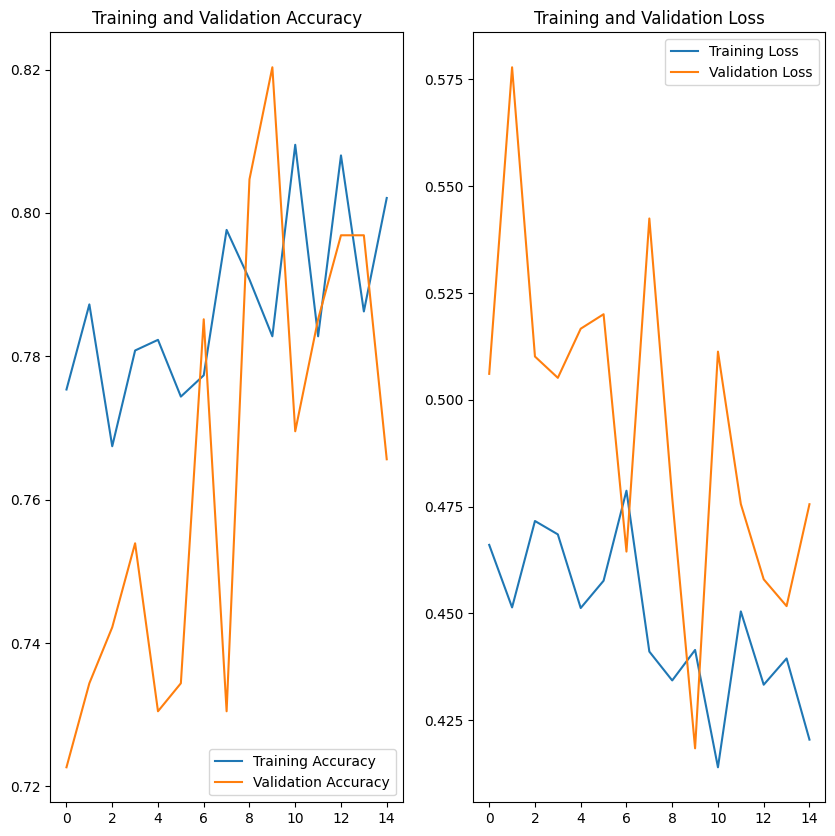

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **MobileNetV2 Transfer Learning**

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Rescaling

base_model_mobilenet_v2 = MobileNetV2(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
base_model_mobilenet_v2.trainable = False  # Freeze the model

model_mobilenet_v2 = Sequential([
    Rescaling(1./255),
    base_model_mobilenet_v2,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model_mobilenet_v2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

9406464/9406464 [==============================] - 1s 0us/step


In [ ]:
base_model_mobilenet_v2.summary()

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15,
)

Epoch 1/15
64/64 [==============================] - 11s 155ms/step - loss: 0.4244 - accuracy: 0.8026 - val_loss: 0.5053 - val_accuracy: 0.7656
Epoch 2/15
64/64 [==============================] - 11s 159ms/step - loss: 0.4270 - accuracy: 0.8046 - val_loss: 0.4618 - val_accuracy: 0.7930
Epoch 3/15
64/64 [==============================] - 11s 155ms/step - loss: 0.4073 - accuracy: 0.8164 - val_loss: 0.4650 - val_accuracy: 0.7891
Epoch 4/15
64/64 [==============================] - 10s 141ms/step - loss: 0.4207 - accuracy: 0.8085 - val_loss: 0.4677 - val_accuracy: 0.8008
Epoch 5/15
64/64 [==============================] - 10s 145ms/step - loss: 0.3926 - accuracy: 0.8125 - val_loss: 0.4920 - val_accuracy: 0.7539
Epoch 6/15
64/64 [==============================] - 11s 163ms/step - loss: 0.4277 - accuracy: 0.7961 - val_loss: 0.4976 - val_accuracy: 0.7891
Epoch 7/15
64/64 [==============================] - 11s 160ms/step - loss: 0.3980 - accuracy: 0.8159 - val_loss: 0.4739 - val_accuracy: 0.7969

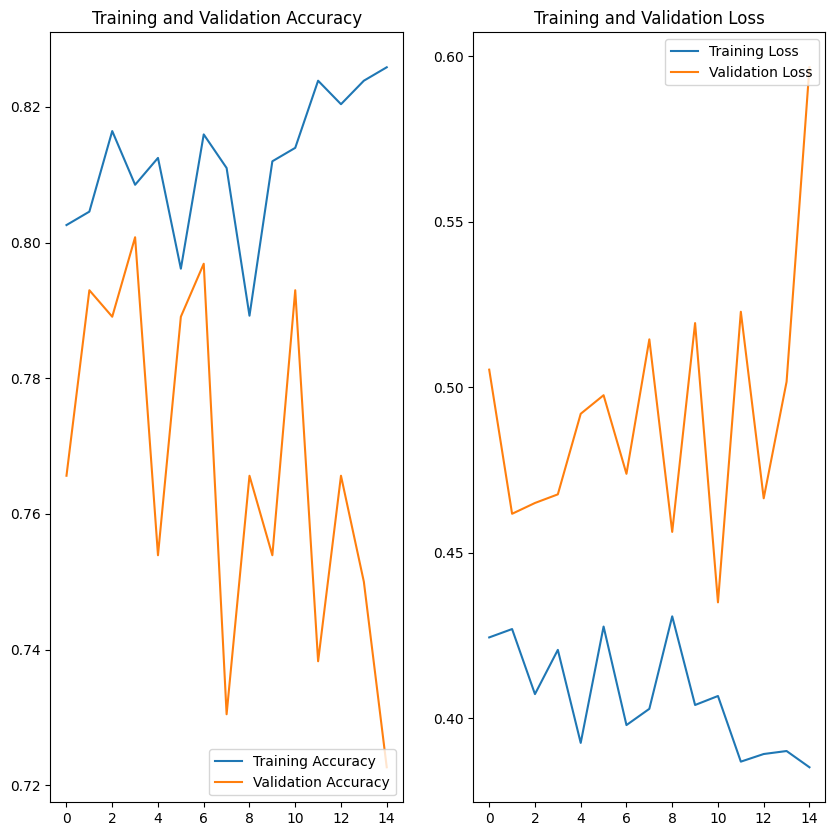

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **ResNet50 Transfer Learning**

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
base_model_resnet50.trainable = False  # Freeze the model

model_resnet50 = Sequential([
    Rescaling(1./255),
    base_model_resnet50,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model_resnet50.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

94765736/94765736 [==============================] - 5s 0us/step


In [ ]:
base_model_resnet50.summary()

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15,
)

Epoch 1/15
64/64 [==============================] - 11s 152ms/step - loss: 0.3756 - accuracy: 0.8273 - val_loss: 0.5607 - val_accuracy: 0.7383
Epoch 2/15
64/64 [==============================] - 11s 167ms/step - loss: 0.3998 - accuracy: 0.8209 - val_loss: 0.5036 - val_accuracy: 0.7852
Epoch 3/15
64/64 [==============================] - 11s 161ms/step - loss: 0.3717 - accuracy: 0.8293 - val_loss: 0.4847 - val_accuracy: 0.7734
Epoch 4/15
64/64 [==============================] - 11s 148ms/step - loss: 0.3786 - accuracy: 0.8234 - val_loss: 0.5614 - val_accuracy: 0.7148
Epoch 5/15
64/64 [==============================] - 11s 160ms/step - loss: 0.3771 - accuracy: 0.8337 - val_loss: 0.5494 - val_accuracy: 0.7500
Epoch 6/15
64/64 [==============================] - 11s 160ms/step - loss: 0.3578 - accuracy: 0.8476 - val_loss: 0.4681 - val_accuracy: 0.7773
Epoch 7/15
64/64 [==============================] - 11s 160ms/step - loss: 0.3781 - accuracy: 0.8357 - val_loss: 0.5208 - val_accuracy: 0.7656

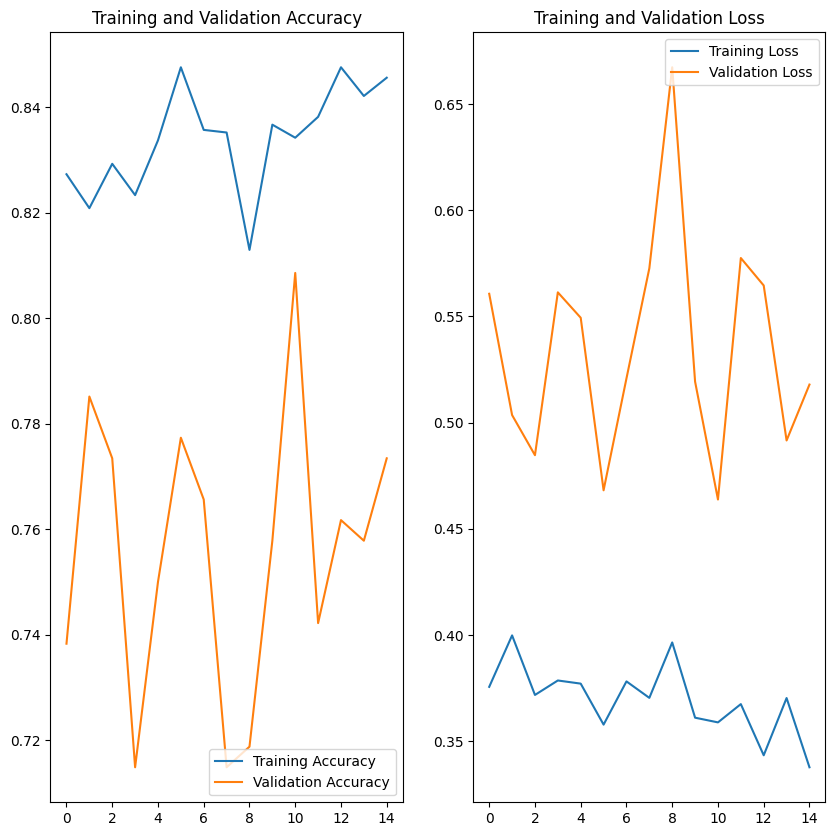

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **MobileNetV2 Transfer Learning (FineTuning)**

In [ ]:
base_model_mobilenet_v2_ft = MobileNetV2(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
base_model_mobilenet_v2_ft.trainable = True  # Unfreeze the model for fine-tuning

# It's common practice to fine-tune only the top layers of the model, so we'll freeze all layers except the last 20.
for layer in base_model_mobilenet_v2_ft.layers[:-20]:
    layer.trainable = False

model_mobilenet_v2_ft = Sequential([
    Rescaling(1./255),
    base_model_mobilenet_v2_ft,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model_mobilenet_v2_ft.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15,
)

Epoch 1/15
64/64 [==============================] - 11s 159ms/step - loss: 0.3597 - accuracy: 0.8308 - val_loss: 0.5777 - val_accuracy: 0.7773
Epoch 2/15
64/64 [==============================] - 10s 144ms/step - loss: 0.3643 - accuracy: 0.8283 - val_loss: 0.4720 - val_accuracy: 0.8242
Epoch 3/15
64/64 [==============================] - 11s 163ms/step - loss: 0.3469 - accuracy: 0.8486 - val_loss: 0.5250 - val_accuracy: 0.7695
Epoch 4/15
64/64 [==============================] - 11s 162ms/step - loss: 0.3354 - accuracy: 0.8560 - val_loss: 0.5769 - val_accuracy: 0.7617
Epoch 5/15
64/64 [==============================] - 11s 155ms/step - loss: 0.3329 - accuracy: 0.8550 - val_loss: 0.5683 - val_accuracy: 0.7383
Epoch 6/15
64/64 [==============================] - 11s 158ms/step - loss: 0.3409 - accuracy: 0.8476 - val_loss: 0.5598 - val_accuracy: 0.7852
Epoch 7/15
64/64 [==============================] - 11s 161ms/step - loss: 0.3528 - accuracy: 0.8466 - val_loss: 0.5825 - val_accuracy: 0.7773

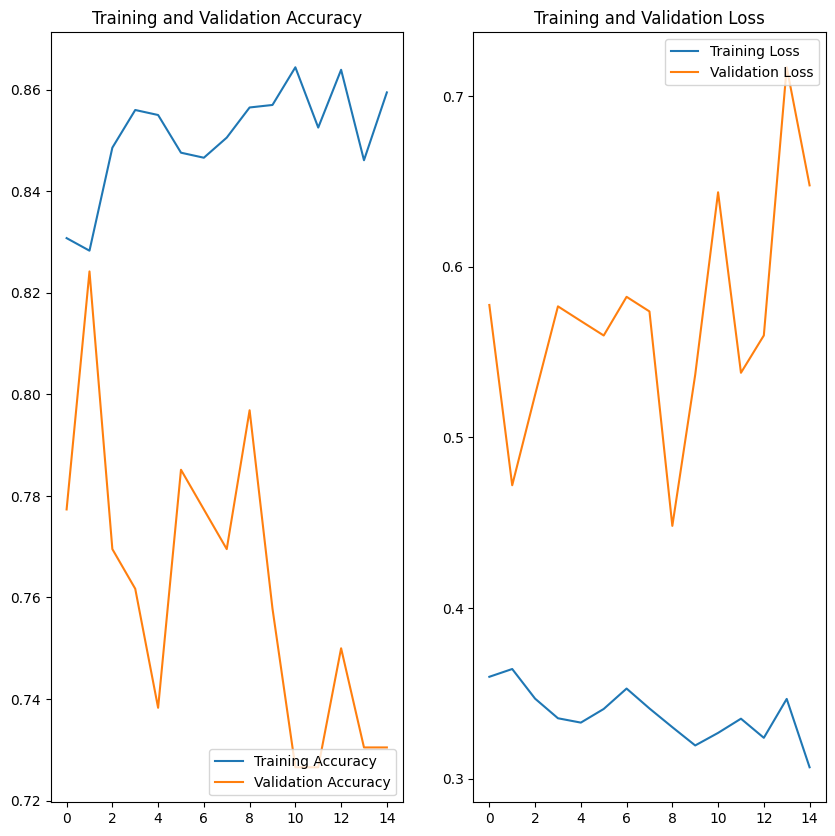

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## **ResNet50 Transfer Learning (FineTuning)**

In [42]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

data_augmentation_resnet = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

base_model_resnet50_ft = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

# Stage 1: freeze the entire pretrained network.
base_model_resnet50_ft.trainable = False

inputs = tf.keras.Input(shape=(180, 180, 3))

x = data_augmentation_resnet(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)

# Keep Batch Normalization in inference mode.
x = base_model_resnet50_ft(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_resnet50_ft = tf.keras.Model(inputs, outputs)

def make_callbacks(checkpoint_name):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            min_delta=0.001,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7
        ),
        ModelCheckpoint(
            checkpoint_name,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True
        )
    ]

# Stage 1: train only the new classifier.
model_resnet50_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

history_head = model_resnet50_ft.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=make_callbacks("resnet_head_best.weights.h5")
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 294ms/step - accuracy: 0.6109 - auc: 0.6478 - loss: 0.7686 - val_accuracy: 0.7148 - val_auc: 0.8286 - val_loss: 0.5490 - learning_rate: 3.0000e-04
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 304ms/step - accuracy: 0.6861 - auc: 0.7577 - loss: 0.6175 - val_accuracy: 0.7031 - val_auc: 0.8114 - val_loss: 0.5571 - learning_rate: 3.0000e-04
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 320ms/step - accuracy: 0.7327 - auc: 0.8052 - loss: 0.5628 - val_accuracy: 0.7656 - val_auc: 0.8591 - val_loss: 0.5094 - learning_rate: 3.0000e-04
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 278ms/step - accuracy: 0.7446 - auc: 0.8229 - loss: 0.5397 - val_accuracy: 0.7734 - val_auc: 0.8623 - val_loss: 0.5043 - learning_rate: 3.0000e-04
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.7347 - auc: 0.8163 - loss: 0.5472 - val_accuracy: 0.8086 - val_auc: 0.9012 - val_loss: 0.4744 - learning_rate: 3.0000e-04
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 273ms/step - 

In [44]:
# Stage 2: fine-tune only the final 20 ResNet layers.
base_model_resnet50_ft.trainable = True

for layer in base_model_resnet50_ft.layers[:-20]:
    layer.trainable = False

for layer in base_model_resnet50_ft.layers[-20:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Recompile after changing trainable layers.
model_resnet50_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

history_resnet50_ft = model_resnet50_ft.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=make_callbacks("resnet_finetuned_best.weights.h5")
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 290ms/step - accuracy: 0.7782 - auc: 0.8666 - loss: 0.4789 - val_accuracy: 0.8125 - val_auc: 0.8922 - val_loss: 0.4484 - learning_rate: 1.0000e-05
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 244ms/step - accuracy: 0.7866 - auc: 0.8660 - loss: 0.4776 - val_accuracy: 0.8438 - val_auc: 0.9125 - val_loss: 0.4316 - learning_rate: 1.0000e-05
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 234ms/step - accuracy: 0.7965 - auc: 0.8805 - loss: 0.4547 - val_accuracy: 0.8281 - val_auc: 0.9067 - val_loss: 0.4343 - learning_rate: 1.0000e-05
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 242ms/step - accuracy: 0.8173 - auc: 0.9000 - loss: 0.4230 - val_accuracy: 0.8320 - val_auc: 0.9379 - val_loss: 0.4029 - learning_rate: 1.0000e-05
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step - accuracy: 0.8124 - auc: 0.8966 - loss: 0.4287 - val_accuracy: 0.8359 - val_auc: 0.9236 - val_loss: 0.4011 - learning_rate: 1.0000e-05
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 223ms/step - 

In [45]:
head_best_loss = min(history_head.history["val_loss"])
finetuned_best_loss = min(history_resnet50_ft.history["val_loss"])

if finetuned_best_loss < head_best_loss:
    best_weights = "resnet_finetuned_best.weights.h5"
else:
    best_weights = "resnet_head_best.weights.h5"

model_resnet50_ft.load_weights(best_weights)

test_results = model_resnet50_ft.evaluate(
    test_ds,
    return_dict=True
)

print("Selected weights:", best_weights)
print("Final held-out test results:", test_results)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 0.8353 - auc: 0.9172 - loss: 0.4003
Selected weights: resnet_finetuned_best.weights.h5
Final held-out test results: {'accuracy': 0.8353413939476013, 'auc': 0.9171829223632812, 'loss': 0.40032294392585754}
